# Keşifsel Veri Analizi (EDA) — Uçtan Uca Örnek Çalışma
Bu defter, sentetik bir müşteri veri seti üzerinde kirli/gerçekçi olmayan verilerin nasıl tespit edilip temizleneceğini ve temel betimsel/görsel analizin nasıl yapılacağını adım adım gösterir.

## 1. Hazırlık ve Ortam Ayarları
- Analiz için gerekli kütüphaneler nasıl içe aktarılır?
- Grafiklerin görsel stili nasıl standart hale getirilir?
- Sonuçların tekrarlanabilir olması için rastgelelik nasıl sabitlenir?
- Pandas görüntüleme ayarları nasıl yapılır?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Grafik stili ve renk paleti standardizasyonu
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 6)

# Tekrarlanabilirlik için rastgelelik sabitleniyor
np.random.seed(42)

# Pandas'ta tüm sütun/satırların ve ondalık sayıların okunabilir gösterimi
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Kütüphaneler ve ayarlar hazır.")

Kütüphaneler ve ayarlar hazır.


## 2. Örnek (Sentetik) Veri Setinin Oluşturulması
- 1000 müşteriden oluşan örnek veri seti nasıl üretilir?
- Şehir isimlerinde kasıtlı yazım farklılıkları nasıl eklenir?

In [2]:
n = 1000

df = pd.DataFrame({
    "musteri_id": range(1, n + 1),
    "yas": np.random.normal(38, 12, n).round(0),
    "gelir": np.random.lognormal(mean=10.5, sigma=0.6, size=n).round(2),
    "sehir": np.random.choice(
        ["İstanbul", "Ankara", "İzmir", "Bursa", "istanbul", "ANKARA"],  # kasıtlı tutarsız yazım
        size=n, p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]
    ),
    "abonelik_tipi": np.random.choice(["Temel", "Standart", "Premium"], size=n, p=[0.5, 0.35, 0.15]),
    "kayit_tarihi": pd.date_range("2022-01-01", periods=n, freq="7h"),
    "aylik_harcama": np.random.gamma(shape=2, scale=150, size=n).round(2),
    "memnuniyet_puani": np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.05, 0.1, 0.2, 0.35, 0.3]),
    "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2]),
})

df.head()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,1,44.00,84087.51,Ankara,Temel,2022-01-01 00:00:00,519.21,4,0
1,2,36.00,63245.56,İstanbul,Standart,2022-01-01 07:00:00,386.18,2,0
2,3,46.00,37638.33,İstanbul,Standart,2022-01-01 14:00:00,1014.04,5,0
3,4,56.00,24632.89,İstanbul,Temel,2022-01-01 21:00:00,59.01,5,0
4,5,35.00,55211.91,istanbul,Standart,2022-01-02 04:00:00,104.91,2,0


## 3. Kasıtlı "Kirli Veri" Enjeksiyonu
- Eksik değerler (gelir, yaş, memnuniyet puanı) nasıl eklenir?
- Gelirde aşırı uç değerler (outlier) nasıl oluşturulur?
- Yaşa mantıksız değerler (-5, 150) nasıl eklenir?
- Kasıtlı yinelenen (duplicate) satırlar nasıl eklenir?

In [3]:
# Eksik değerler
df.loc[df.sample(frac=0.08, random_state=1).index, "gelir"] = np.nan
df.loc[df.sample(frac=0.05, random_state=2).index, "yas"] = np.nan
df.loc[df.sample(frac=0.03, random_state=3).index, "memnuniyet_puani"] = np.nan

# Gelirde uç değerler (outlier)
outlier_idx = df.sample(frac=0.01, random_state=4).index
df.loc[outlier_idx, "gelir"] = df["gelir"].max() * np.random.uniform(3, 6, len(outlier_idx))

# Yaşta mantık dışı değerler
df.loc[df.sample(frac=0.005, random_state=5).index, "yas"] = -5
df.loc[df.sample(frac=0.005, random_state=6).index, "yas"] = 150

# Kasıtlı yinelenen satırlar
df = pd.concat([df, df.sample(5, random_state=7)], ignore_index=True)

print(f"Veri Seti: {df.shape[0]} satır, {df.shape[1]} sütun")

Veri Seti: 1005 satır, 9 sütun


## 4. Veri Setine Genel Bakış
- Veri setinin boyutu (satır/sütun sayısı) nasıl kontrol edilir?
- Sütun veri tipleri ve dolu/boş hücre sayıları (`.info()`) nasıl incelenir?
- İlk, son ve rastgele seçilmiş satırlar nasıl görüntülenir?

In [4]:
# Boyut kontrolü
print(f"Veri Seti: {df.shape[0]} satır, {df.shape[1]} sütun")
df.shape

Veri Seti: 1005 satır, 9 sütun


(1005, 9)

In [5]:
# Sütun tipleri ve dolu/boş hücre sayıları
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   musteri_id        1005 non-null   int64         
 1   yas               956 non-null    float64       
 2   gelir             926 non-null    float64       
 3   sehir             1005 non-null   str           
 4   abonelik_tipi     1005 non-null   str           
 5   kayit_tarihi      1005 non-null   datetime64[us]
 6   aylik_harcama     1005 non-null   float64       
 7   memnuniyet_puani  975 non-null    float64       
 8   churn             1005 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(2)
memory usage: 70.8 KB


In [6]:
# İlk satırlar
df.head()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,1,44.00,84087.51,Ankara,Temel,2022-01-01 00:00:00,519.21,4.00,0
1,2,36.00,63245.56,İstanbul,Standart,2022-01-01 07:00:00,386.18,2.00,0
2,3,46.00,37638.33,İstanbul,Standart,2022-01-01 14:00:00,1014.04,5.00,0
3,4,56.00,24632.89,İstanbul,Temel,2022-01-01 21:00:00,59.01,5.00,0
4,5,35.00,55211.91,istanbul,Standart,2022-01-02 04:00:00,104.91,2.00,0


In [7]:
# Son satırlar
df.tail()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
1000,779,37.00,28068.93,istanbul,Temel,2022-08-15 22:00:00,420.46,4.00,0
1001,335,50.00,39703.73,İstanbul,Premium,2022-04-08 10:00:00,272.02,3.00,0
1002,272,21.00,52338.26,Ankara,Temel,2022-03-21 01:00:00,456.14,3.00,0
1003,803,39.00,23740.93,İstanbul,Standart,2022-08-22 22:00:00,520.06,4.00,0
1004,217,29.00,24243.54,İstanbul,Temel,2022-03-05 00:00:00,838.08,3.00,0


In [8]:
# Rastgele seçilmiş satırlar
df.sample(5, random_state=1)

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
685,686,47.00,NaN,İstanbul,Premium,2022-07-19 19:00:00,390.24,3.00,0
614,615,67.00,NaN,İstanbul,Standart,2022-06-29 02:00:00,149.73,4.00,0
602,603,48.00,24647.27,İzmir,Temel,2022-06-25 14:00:00,234.32,4.00,1
502,503,21.00,NaN,İstanbul,Premium,2022-05-27 10:00:00,400.23,4.00,0
341,342,41.00,36381.93,istanbul,Temel,2022-04-10 11:00:00,35.14,4.00,0


## 5. Eksik Değer Analizi
- Her sütundaki eksik değer sayısı, benzersiz değer sayısı ve eksik değer yüzdesi nasıl özetlenir?
- Eksik değerlerin dağılımı bir ısı haritası (heatmap) ile nasıl görselleştirilir?

In [9]:
print("\n---- Sütun Özeti ----")
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "eksik_deger": df.isnull().sum(),
    "unique_deger": df.nunique(),
    "eksik_deger_yuzdesi": (df.isnull().mean() * 100).round(2),
})
print(ozet)


---- Sütun Özeti ----
                           dtype  eksik_deger  unique_deger  \
musteri_id                 int64            0          1000   
yas                      float64           49            70   
gelir                    float64           79           921   
sehir                        str            0             6   
abonelik_tipi                str            0             3   
kayit_tarihi      datetime64[us]            0          1000   
aylik_harcama            float64            0           995   
memnuniyet_puani         float64           30             5   
churn                      int64            0             2   

                  eksik_deger_yuzdesi  
musteri_id                       0.00  
yas                              4.88  
gelir                            7.86  
sehir                            0.00  
abonelik_tipi                    0.00  
kayit_tarihi                     0.00  
aylik_harcama                    0.00  
memnuniyet_puani          

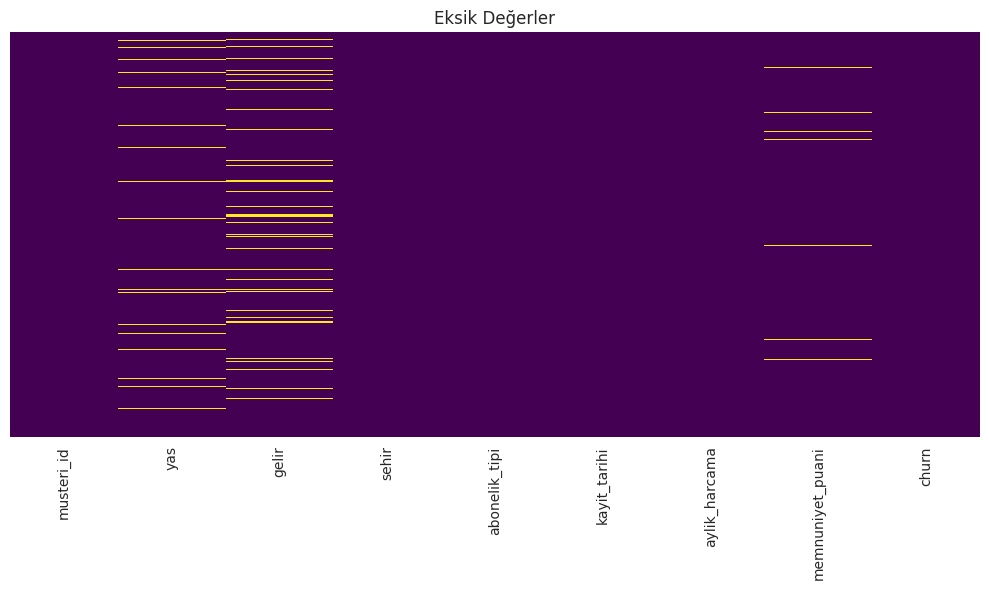

In [10]:
# Eksik değerlerin heatmap ile görselleştirilmesi
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Eksik Değerler")
plt.tight_layout()
plt.savefig("eksik_degerler.png", dpi=300)
plt.show()

## 6. Yinelenen Kayıtların Tespiti
- Veri setinde kaç adet birebir aynı (duplicate) satır bulunuyor?

In [11]:
n_dup = df.duplicated().sum()
print(f"Birebir aynı (duplicate) satır sayısı: {n_dup}")
n_dup

Birebir aynı (duplicate) satır sayısı: 5


np.int64(5)

## 7. Kategorik Veri Temizliği
- "Şehir" sütunundaki tutarsız yazımların dağılımı nasıl görüntülenir?
- Şehir isimleri küçük harfe çevrilip boşluklardan nasıl arındırılır?

In [12]:
# Temizlik öncesi tutarsız yazımların dağılımı
print(df["sehir"].value_counts())

sehir
İstanbul    361
Ankara      190
İzmir       150
Bursa       109
istanbul    101
ANKARA       94
Name: count, dtype: int64


In [13]:
# Küçük harfe çevirme ve baştaki/sondaki boşluklardan arındırma
df["sehir"] = df["sehir"].str.lower().str.strip()

print("Temizlik sonrası:")
print(df["sehir"].value_counts())

Temizlik sonrası:
sehir
i̇stanbul    361
ankara       284
i̇zmir       150
bursa        109
istanbul     101
Name: count, dtype: int64


## 8. Mantık Dışı (Anomali) Değerlerin Tespiti
- 0'ın altında veya 100'ün üzerinde olan, gerçekçi olmayan yaş değerlerine sahip müşteriler nasıl bulunur?

In [14]:
anomali_yas = df[(df["yas"] < 0) | (df["yas"] > 100)][["musteri_id", "yas"]]
print(anomali_yas)
anomali_yas

     musteri_id    yas
11           12  -5.00
22           23 150.00
193         194  -5.00
262         263  -1.00
279         280  -5.00
399         400 150.00
438         439 150.00
515         516  -5.00
544         545  -5.00
909         910 150.00
978         979 150.00


,musteri_id,yas
11,12,-5.00
22,23,150.00
193,194,-5.00
262,263,-1.00
279,280,-5.00
399,400,150.00
438,439,150.00
515,516,-5.00
544,545,-5.00
909,910,150.00


## 9. Betimsel İstatistikler
- Sayısal sütunların temel istatistiksel özeti (ortalama, medyan, std, min/max vb.) nasıl elde edilir?
- Çarpıklık (skewness) ve basıklık (kurtosis) değerleri nasıl hesaplanır?

In [15]:
df.describe()

,musteri_id,yas,gelir,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
count,1005.00,956.00,926.00,1005,1005.00,975.00,1005.00
mean,500.40,38.61,57050.67,2022-05-26 15:49:40.298507,296.50,3.69,0.18
min,1.00,-5.00,6292.98,2022-01-01 00:00:00,4.54,1.00,0.00
25%,251.00,30.00,25195.60,2022-03-14 22:00:00,148.91,3.00,0.00
50%,500.00,38.00,38028.92,2022-05-26 13:00:00,251.53,4.00,0.00
75%,751.00,46.00,56173.36,2022-08-07 18:00:00,402.07,5.00,0.00
max,1000.00,150.00,1377244.81,2022-10-19 09:00:00,1550.69,5.00,1.00
std,288.67,14.47,120750.24,NaN,205.66,1.12,0.39


In [16]:
print("\n---- Çarpıklık / Basıklık ----")

sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns.tolist()
sayisal_sutunlar.remove("musteri_id")

for col in sayisal_sutunlar:
    print(f"{col:20s} skew: {df[col].skew():6.2f}   kurt: {df[col].kurt():6.2f}")


---- Çarpıklık / Basıklık ----
yas                  skew:   2.28   kurt:  17.21
gelir                skew:   8.95   kurt:  83.96
aylik_harcama        skew:   1.43   kurt:   3.40
memnuniyet_puani     skew:  -0.73   kurt:  -0.15
churn                skew:   1.63   kurt:   0.67


## 10. Dağılım Görselleştirmeleri
- Sayısal değişkenlerin dağılımları histogram ve yoğunluk eğrisi (KDE) ile nasıl gösterilir?
- Aykırı değerler kutu grafiği (boxplot) ile nasıl görselleştirilir?

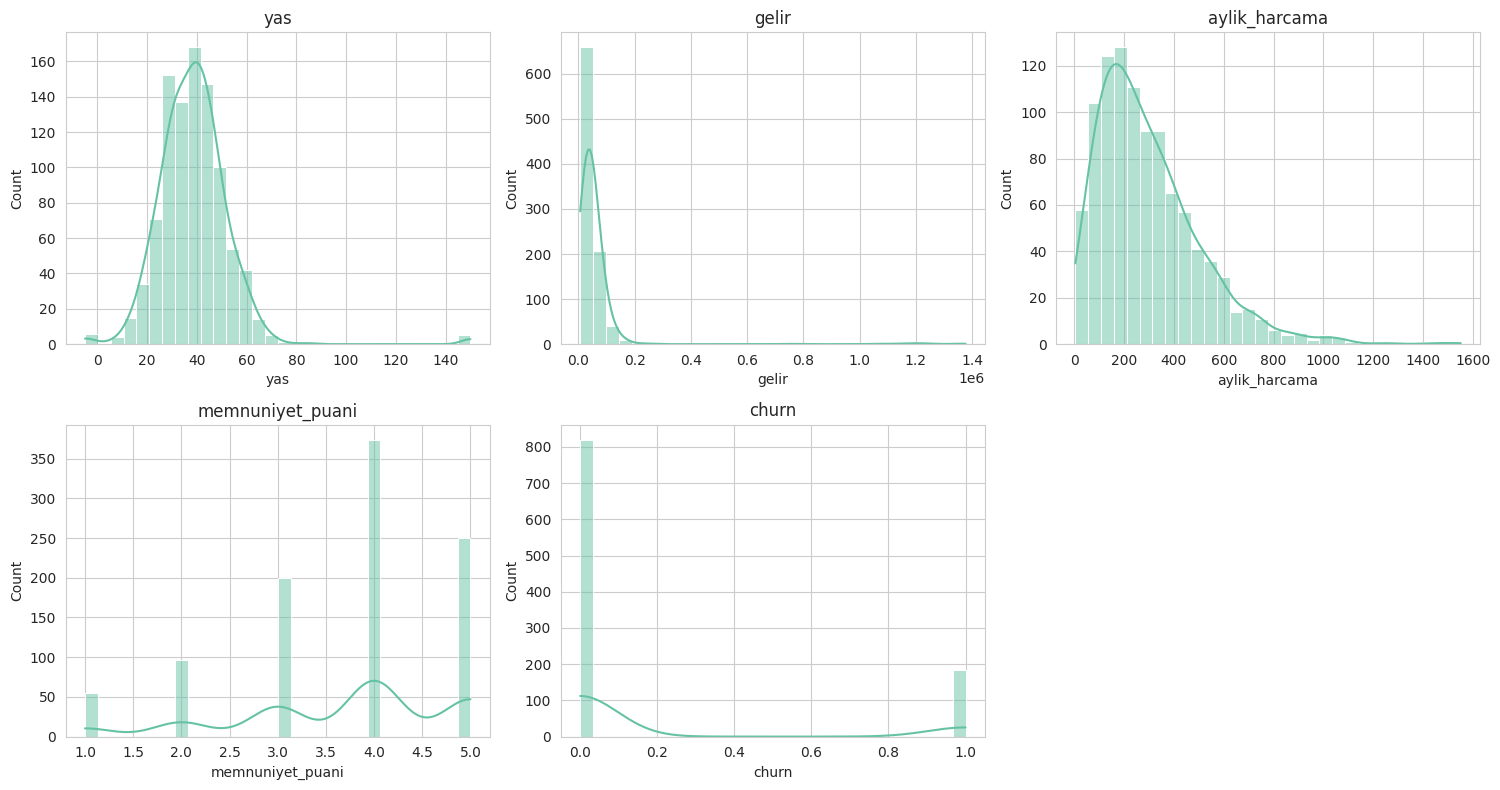

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), sayisal_sutunlar):
    sns.histplot(df[col], ax=ax, kde=True, bins=30)
    ax.set_title(col)
# Kullanılmayan eksenleri gizle
for ax in axes.flatten()[len(sayisal_sutunlar):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("histogramlar.png", dpi=300)
plt.show()

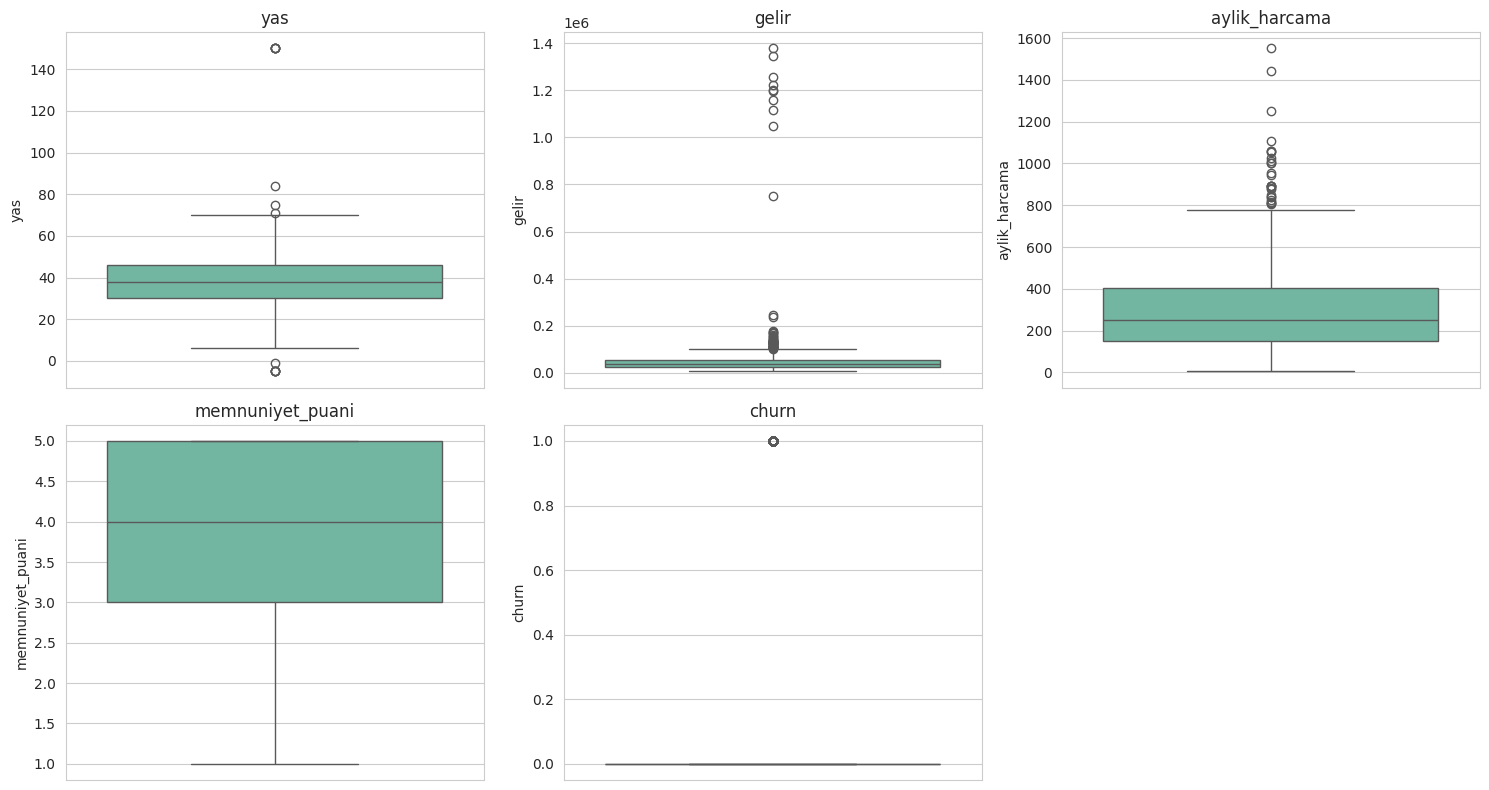

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), sayisal_sutunlar):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[len(sayisal_sutunlar):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("boxplot.png", dpi=300)
plt.show()

## 11. Kategorik Değişken Analizi
- Kategorik sütunların (şehir, abonelik tipi, memnuniyet puanı, churn) yüzdesel dağılımı nasıl hesaplanır?

In [19]:
kategorik_sutunlar = ["sehir", "abonelik_tipi", "memnuniyet_puani", "churn"]
for col in kategorik_sutunlar:
    print(f"\n---- {col} ----")
    print((df[col].value_counts(dropna=False, normalize=True) * 100).round(2))


---- sehir ----
sehir
i̇stanbul   35.92
ankara      28.26
i̇zmir      14.93
bursa       10.85
istanbul    10.05
Name: proportion, dtype: float64

---- abonelik_tipi ----
abonelik_tipi
Temel      51.74
Standart   35.92
Premium    12.34
Name: proportion, dtype: float64

---- memnuniyet_puani ----
memnuniyet_puani
4.00   37.21
5.00   24.88
3.00   19.90
2.00    9.55
1.00    5.47
NaN     2.99
Name: proportion, dtype: float64

---- churn ----
churn
0   81.59
1   18.41
Name: proportion, dtype: float64


## 12. Korelasyon Analizi
- Sayısal değişkenler arasındaki korelasyon matrisi nasıl hesaplanır?
- Korelasyon matrisi bir ısı haritası ile nasıl görselleştirilir?

In [20]:
korelasyon = df[sayisal_sutunlar].corr(numeric_only=True)
print("---- Korelasyon Matrisi ----")
print(korelasyon.round(2))
korelasyon

---- Korelasyon Matrisi ----
                   yas  gelir  aylik_harcama  memnuniyet_puani  churn
yas               1.00   0.02          -0.00              0.04  -0.07
gelir             0.02   1.00          -0.04              0.01  -0.04
aylik_harcama    -0.00  -0.04           1.00              0.07  -0.02
memnuniyet_puani  0.04   0.01           0.07              1.00  -0.02
churn            -0.07  -0.04          -0.02             -0.02   1.00


,yas,gelir,aylik_harcama,memnuniyet_puani,churn
yas,1.00,0.02,-0.00,0.04,-0.07
gelir,0.02,1.00,-0.04,0.01,-0.04
aylik_harcama,-0.00,-0.04,1.00,0.07,-0.02
memnuniyet_puani,0.04,0.01,0.07,1.00,-0.02
churn,-0.07,-0.04,-0.02,-0.02,1.00


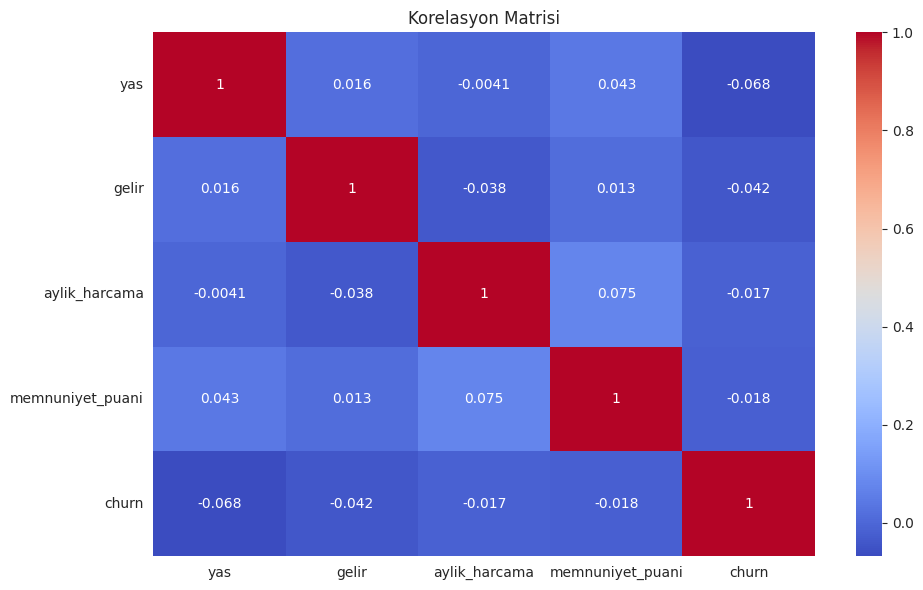

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(korelasyon, annot=True, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.savefig("korelasyon_matrisi.png", dpi=300)
plt.show()

## Özet
Bu defterde sentetik ama kasıtlı olarak "kirletilmiş" bir müşteri veri seti üzerinden tipik bir EDA akışı uygulandı: eksik değer analizi, yinelenen kayıt tespiti, kategorik verilerin standartlaştırılması, mantık dışı değerlerin (anomali) tespiti, betimsel istatistikler ve dağılım/korelasyon görselleştirmeleri. Bu adımlar, herhangi bir gerçek veri setine uygulanmadan önce izlenmesi gereken standart bir kontrol listesi olarak kullanılabilir.